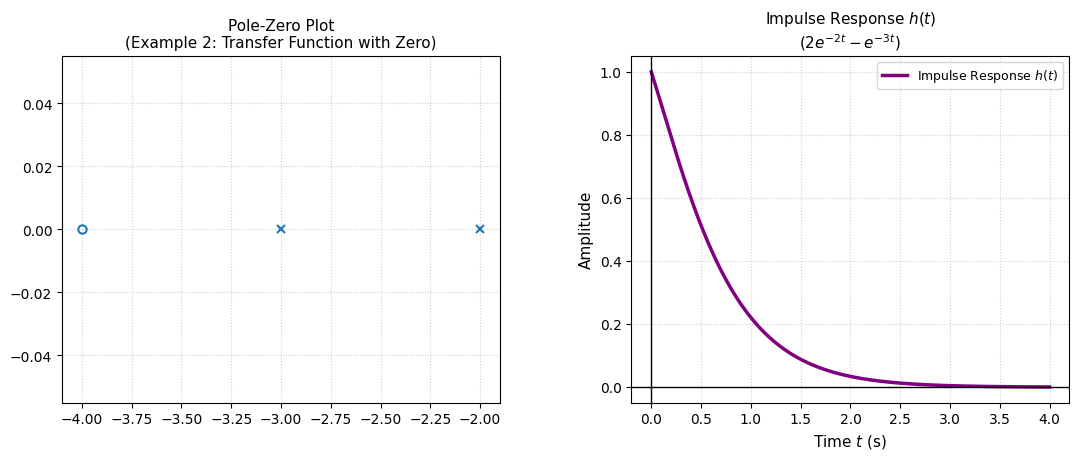

=== Transfer Function & Impulse Analysis (Example 2) ===
• Transfer Function H(s): <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 4
  -------------
  s^2 + 5 s + 6
• Poles: [-3.+0.j -2.+0.j]
• Zeros: [-4.+0.j]
• BIBO Stability Status: Stable (All poles in LHP)


In [1]:
# Notebook: Transfer Function with Numerator Dynamics & Impulse Response (Example 2)
import numpy as np
import matplotlib.pyplot as plt
import control as ct
import ipywidgets as widgets
from ipywidgets import interact

# Ορισμός του συστήματος του Παραδείγματος 2
# Differential equation: y''(t) + 5y'(t) + 6y(t) = x'(t) + 4x(t)
# Αριθμητής (Numerator): [1, 4]  -> αντιστοιχεί σε 1*s + 4
# Παρονομαστής (Denominator): [1, 5, 6] -> αντιστοιχεί σε s^2 + 5s + 6
num = [1, 4]
den = [1, 5, 6]
H = ct.tf(num, den)

def analyze_example2():
    # Υπολογισμός πόλων, μηδενικών και ευστάθειας
    p = ct.poles(H)
    z = ct.zeros(H)
    is_stable = all(np.real(p) < 0)
    
    # Δημιουργία γραφημάτων (Pole-Zero map & Impulse Response)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.subplots_adjust(wspace=0.3)
    
    # --- 1. Pole-Zero Plot ---
    ct.pzmap(H, ax=ax1, title='Pole-Zero Map (Example 2)')
    ax1.set_title('Pole-Zero Plot\n(Example 2: Transfer Function with Zero)', fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- 2. Impulse Response h(t) ---
    t_out, h_out = ct.impulse_response(H, T=np.linspace(0, 4, 500))
    ax2.plot(t_out, h_out, color='purple', lw=2.5, label='Impulse Response $h(t)$')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axvline(0, color='black', linewidth=1)
    ax2.set_xlabel('Time $t$ (s)', fontsize=11)
    ax2.set_ylabel('Amplitude', fontsize=11)
    ax2.set_title('Impulse Response $h(t)$\n($2e^{-2t} - e^{-3t}$)', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='best', frameon=True, fontsize=9)
    
    plt.show()
    
    # Εκτύπωση αποτελεσμάτων
    stability_text = "Stable (All poles in LHP)" if is_stable else "Unstable"
    
    print("=== Transfer Function & Impulse Analysis (Example 2) ===")
    print(f"• Transfer Function H(s): {H}")
    print(f"• Poles: {np.round(p, 4)}")
    print(f"• Zeros: {np.round(z, 4) if len(z) > 0 else 'None'}")
    print(f"• BIBO Stability Status: {stability_text}")

# Εκτέλεση ανάλυσης
analyze_example2()